# Bandit Problem

In [1]:
# imports
from bandits import Bandit
import random
# Include your imports here, if any are used. 
import numpy as np
import matplotlib.pyplot as plt

A list of ten bandit objects initialized in the list...

In [2]:
bandits = [Bandit(random.random()*4-2) for _ in range(10)]

In [3]:
bandits[0].pullLever()

-3.683640109498654

## Greedy algorithm Implementation

In [4]:
# Return the reward from the bandits in a list
T = 1000
def run_greedy(bandits,T):
    k= len(bandits)
    count = [0]*k
    estimate = [0.0]*k
    rewards = []
    for x in range(k):
        r = bandits[x].pullLever()
        rewards.append(r)
        count[x]+=1
        estimate[x]=r
    for x in range(k,T):
        arm = estimate.index(max(estimate))
        r = bandits[arm].pullLever()
        rewards.append(r)
        count[arm]+=1
        estimate[arm] += (r-estimate[arm])/count[arm]
    return rewards

Plot the cumulative average of rewards as the number of iterations increases.

In [5]:
num_of_runs = 100
allrewards = []
for _ in range(num_of_runs) :
    rewards = run_greedy(bandits,T)
    allrewards.append(rewards)

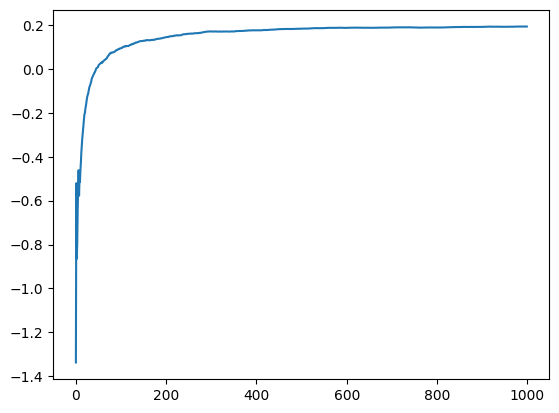

In [6]:
mean_rewards = np.mean(allrewards, axis=0)
cum_avg = np.cumsum(mean_rewards)/np.arange(1,T+1)
plt.plot(cum_avg)
plt.show()

## $\epsilon$-greedy Algorithm

In [7]:
# Return the reward from the bandits in a list
T = 1000
def run_epsilon_greedy(bandits,epsilon,T):
    k= len(bandits)
    count = [0]*k
    estimate = [0.0]*k
    rewards = []
    for x in range(k):
        r = bandits[x].pullLever()
        rewards.append(r)
        count[x]+=1
        estimate[x]=r
    for x in range(k,T):
        l=np.random.rand()
        if(l>epsilon):
            arm = estimate.index(max(estimate))
            r = bandits[arm].pullLever()
            rewards.append(r)
            count[arm]+=1
            estimate[arm] += (r-estimate[arm])/count[arm]
        else:
            arm = np.random.randint(0,k)
            r = bandits[arm].pullLever()
            rewards.append(r)
            count[arm]+=1
            estimate[arm] += (r-estimate[arm])/count[arm]
    return rewards
 

Plot the cumulative average of rewards as the number of iterations increases but for various values of $\epsilon$.

In [8]:
num_of_runs =10
epsilon_list = np.arange(11)*0.1
rewards_list = []
for epsilon in epsilon_list:
    rewards_for_epsilon = []
    for _ in range(num_of_runs):
        rewards = run_epsilon_greedy(bandits,epsilon,T)
        rewards_for_epsilon.append(rewards)
    rewards_list.append(rewards_for_epsilon)     


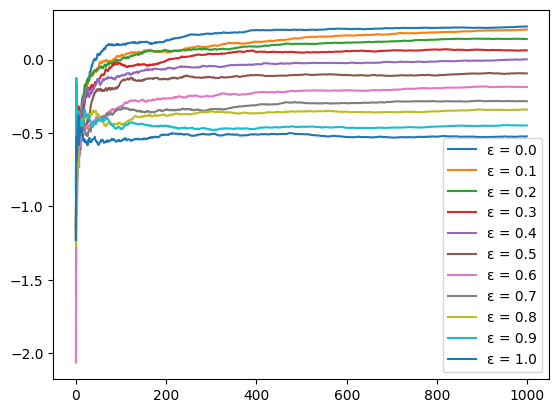

In [9]:
cum_avg_epsilon = []
for x in range(0,11):
    mean_for_epsilon = np.mean(rewards_list[x], axis=0)
    cum_avg = np.cumsum(mean_for_epsilon)/np.arange(1,T+1)
    plt.plot(cum_avg,label=f"ε = {(x*0.1):.1f}")
    cum_avg_epsilon.append(cum_avg)
plt.legend()
plt.show()

## Finding the optimal $\epsilon$

Run the $\epsilon$-greedy algorithm for 1000 iterations and find the optimal $\epsilon$ value by plotting the cumulative average of rewards for various values of $\epsilon$

In [10]:
last_value = []
for x in range(0,11):
    last_value.append(cum_avg_epsilon[x][-1])
x = last_value.index(max(last_value))

In [11]:
print("The optimal value of ε is",x)

The optimal value of ε is 0


## Optimistic Initial Values

In [15]:
# Return the reward from the bandits in a list
T = 1000
def run_optimistic_greedy():
    k= len(bandits)
    count = [0]*k
    estimate = [10]*k
    rewards = []
    for x in range(k,T):
        arm = estimate.index(max(estimate))
        r = bandits[arm].pullLever()
        rewards.append(r)
        count[arm]+=1
        estimate[arm] += (r-estimate[arm])/count[arm]
    return rewards

Plot the cumulative average of rewards as the number of iterations increases for an optimistic greedy of $Q_1 = 10$ and a non-optimistic $\epsilon = 0.1$

In [16]:
num_of_runs = 100
allrewards = []
egreedy = []
for _ in range(num_of_runs) :
    rewards = run_greedy(bandits,T)
    allrewards.append(rewards)
    reward = run_epsilon_greedy(bandits,0.1,T)
    egreedy.append(reward)



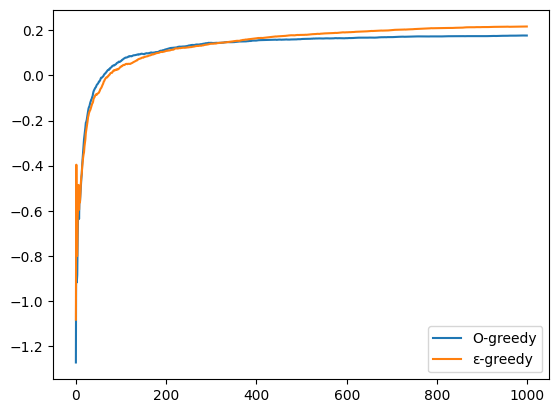

In [18]:
mean_rewards = np.mean(allrewards, axis=0)
mean_rewards_e = np.mean(egreedy,axis=0)
cum_avg = np.cumsum(mean_rewards)/np.arange(1,T+1)
cum_avg_e = np.cumsum(mean_rewards_e)/np.arange(1,T+1)
plt.plot(cum_avg, label="O-greedy")
plt.plot(cum_avg_e, label="ε-greedy")
plt.legend()
plt.show()

## Optional - Upper Confidence Bound (UCB)

In [7]:
def run_ucb(c):
    # TODO: Implement the UCB algorithm here
    # Return the reward from the bandits in a list
    pass